<a href="https://colab.research.google.com/github/Sj-kronton/IA_2025/blob/main/modelo_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##crear el modelo para pasarlo a Raspberry

1. instalar

In [1]:
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 133.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


2. descargar eñ dataset desde roboflow

In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="fg4aUhwvwxfe7SWv6bk3")
project = rf.workspace("sj-ytwh0").project("custom_face_detector_yolo11-tjmpm")
version = project.version(2)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to custom_face_detector_yolo11-2 in yolov11:: 100%|██████████| 152/152 [00:00<00:00, 9024.99it/s]


3. cargar el modelo base de YOLOV11

In [3]:
from ultralytics import YOLO

model = YOLO('yolo11s.pt')

4. Entrenar el modelo

In [4]:
data_path="/content/custom_face_detector_yolo11-2/data.yaml"
results=model.train(data=data_path,
                    epochs=15,
                    imgsz=640)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/custom_face_detector_yolo11-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

5. hacer predicciones

In [11]:
#asignarle a una variable el mejor modelo
custom_model=YOLO('/content/runs/detect/train/weights/best.pt')


In [12]:
#asignar una variable, o mas bien, matriz, que utilice el modelo para predecir las imagenes de testeo
res = custom_model("/content/custom_face_detector_yolo11-2/test/images")
#los datos a continuacion son los resultados de las predicciones, al final de cada fila se indica cuales y cuantos objetos se encontraron en las imagenes


image 1/7 /content/custom_face_detector_yolo11-2/test/images/IMG20251113132729_jpg.rf.52d35766306a6f5b6a8418f152019101.jpg: 640x640 1 SJ, 15.6ms
image 2/7 /content/custom_face_detector_yolo11-2/test/images/IMG20251113132731_jpg.rf.80d454035512e0521f8ae086dfa69006.jpg: 640x640 1 SJ, 15.5ms
image 3/7 /content/custom_face_detector_yolo11-2/test/images/IMG20251113132734_jpg.rf.55752768060b31494f90737c6758f3d6.jpg: 640x640 1 SJ, 15.5ms
image 4/7 /content/custom_face_detector_yolo11-2/test/images/IMG20251113132810_jpg.rf.6ff4bab5f656c0677c79829dbad1c18d.jpg: 640x640 1 SJ, 15.6ms
image 5/7 /content/custom_face_detector_yolo11-2/test/images/IMG20251113132905_jpg.rf.cb94800ea0eb0ffd208595c84fcaf5ca.jpg: 640x640 1 SJ, 15.6ms
image 6/7 /content/custom_face_detector_yolo11-2/test/images/IMG20251113133248_jpg.rf.a2e34afe00d01d418d615354e984c21d.jpg: 640x640 1 SJ, 15.5ms
image 7/7 /content/custom_face_detector_yolo11-2/test/images/IMG20251113133845_jpg.rf.e1aed777d6b53c4c5bbe370da9f8ff2d.jpg: 640x6

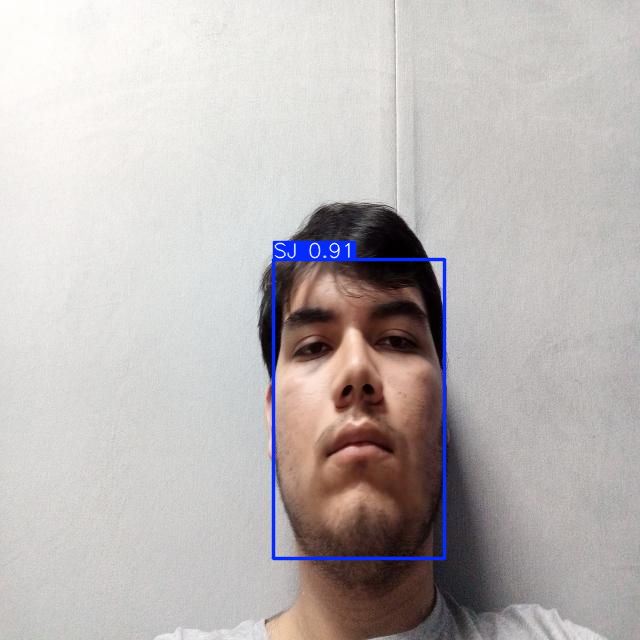

In [13]:
#mostrar el resultado de las predicciones en imagenes
res[6].show()